# **Warehouse Efficiency Analysis:**

### **1. Warehouse Performance Baseline Establishment:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
from datetime import datetime   

In [4]:
data= pd.read_json('ecommerce_shipping_data.json')
data.shape

(10999, 12)

In [5]:
data.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [6]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.1+ MB


In [8]:
data.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [19]:
data.select_dtypes(include= ["number"]).columns

Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [14]:
data.select_dtypes(include= ["category"]).columns

Index([], dtype='object')

In [15]:
data.select_dtypes(include= ["object"]).columns

Index(['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender'], dtype='object')

In [21]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [45]:
a= data.groupby(by= "Warehouse_block")["Reached.on.Time_Y.N"].value_counts(normalize= True).reset_index()
a

,Warehouse_block,Reached.on.Time_Y.N,proportion
0,A,1,0.586470
1,A,0,0.413530
2,B,1,0.602291
3,B,0,0.397709
4,C,1,0.596836
5,C,0,0.403164
6,D,1,0.597601
7,D,0,0.402399
8,F,1,0.598472
9,F,0,0.401528


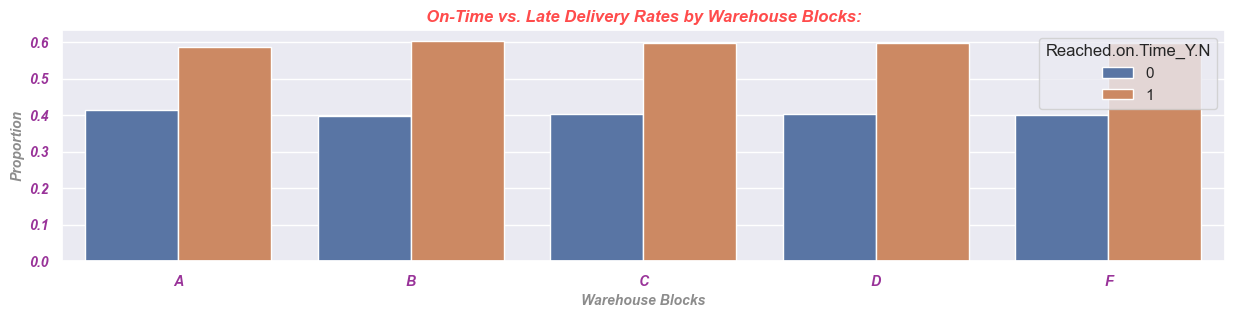

In [48]:
plt.figure(figsize= (15, 3))
sns.set_theme(context= "notebook", style= "darkgrid", palette= "bright6", font= "sans-serif", font_scale= 1, color_codes= True, rc= None)
sns.barplot(data= a, x= "Warehouse_block", y= "proportion", hue= "Reached.on.Time_Y.N", palette= "deep")
plt.title("On-Time vs. Late Delivery Rates by Warehouse Blocks:", fontsize= 12, fontweight= "bold", fontstyle= "italic", color= "red", alpha= 0.7)  
plt.xlabel("Warehouse Blocks", fontsize= 10, fontweight= "bold", fontstyle= "italic", color= "gray", alpha= 0.9)
plt.ylabel("Proportion", fontsize= 10, fontweight= "bold", fontstyle= "italic", color= "gray", alpha= 0.9)
plt.xticks(color= "purple", alpha= 0.8, fontsize= 10, fontweight= "bold", fontstyle= "italic")
plt.yticks(color= "purple", alpha= 0.8, fontsize= 10, fontweight= "bold", fontstyle= "italic")
plt.show()

In [30]:
b= pd.pivot_table(data= a, index= "Reached.on.Time_Y.N", columns= "Warehouse_block", values= "proportion")
b

Warehouse_block,A,B,C,D,F
Reached.on.Time_Y.N,,,,,
0,0.41353,0.397709,0.403164,0.402399,0.401528
1,0.58647,0.602291,0.596836,0.597601,0.598472


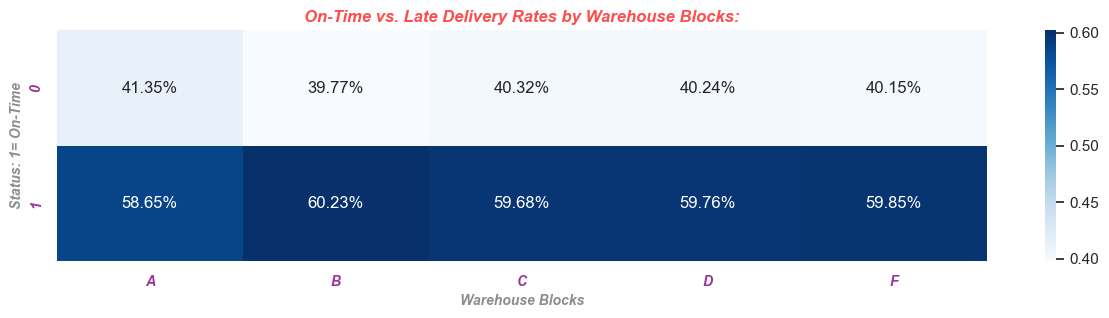

In [44]:
plt.figure(figsize= (15, 3))
sns.set_theme(context= "notebook", style= "darkgrid", palette= "deep", font= "sans-serif", font_scale= 1, color_codes= True, rc= None)
sns.heatmap(data= b, cmap= "Blues", annot= True, fmt= ".2%", ) 
plt.title("On-Time vs. Late Delivery Rates by Warehouse Blocks:", fontsize= 12, fontweight= "bold", fontstyle= "italic", color= "red", alpha= 0.7)
plt.xlabel("Warehouse Blocks", fontsize= 10, fontweight= "bold", fontstyle= "italic", color= "gray", alpha= 0.9)
plt.ylabel("Status: 1= On-Time", fontsize= 10, fontweight= "bold", fontstyle= "italic", color= "gray", alpha= 0.9)
plt.xticks(fontsize= 10, fontweight= "bold", fontstyle= "italic", color= "purple", alpha= 0.8)
plt.yticks(fontsize= 10, fontweight= "bold", fontstyle= "italic", color= "purple", alpha= 0.8)
plt.show()

On-Time delively rate for different warehouses lies `between 58 to 60%`. The difference is very minute and to conclude if the on-time delivery rates differ significantly, we will make use of Inferencial Statistics. 

#### **Statistical Hypothesis Testing:**

We are testing whether **on-time delivery rate differs across warehouses**. Since this is a test of categorical variables (warehouse vs. delivery status), we use the **`Chi-Square Test of Independence`**.

> * **`Null Hypothesis` $(H₀)$**: On-time delivery rate is the **`same`** across all warehouses — i.e., *on-time delivery is independent of the warehouse block*.

> * **`Alternative Hypothesis` $(H₁)$**: On-time delivery rate is **`different`** across at least one warehouse — i.e., *there is a dependency between warehouse block and delivery status*.

In [53]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

**Summary Statistics for each Warehouse Block:**